<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/N1217583%20AI%20Final%20Year%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Year Project:

In [ ]:
import tensorflow as tf
import sys

print(f"Python version   : {sys.version.split()[0]}")
print(f"TensorFlow version: {tf.__version__}")

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU detected      : {gpu_devices[0].name}")
else:
    print("No GPU detected — go to Runtime > Change runtime type > GPU (T4) before training.")

import numpy as np
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"\nAll random seeds fixed to {SEED} for reproducibility.")

Python version   : 3.12.13
TensorFlow version: 2.20.0
No GPU detected — go to Runtime > Change runtime type > GPU (T4) before training.

All random seeds fixed to 42 for reproducibility.


# Importing all the libraries

In [ ]:
# -- Data handling & numerics --
import numpy as np
import pandas as pd

# -- Visualisation --
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# -- File / OS operations --
import os
import shutil
import random as pyrandom

# -- Image processing (used later for the damage-severity module) --
import cv2
from PIL import Image

# -- Deep learning --
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -- Evaluation --
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries loaded.")

Libraries loaded.


# Importing Dataset

In [ ]:
!pip install -q kaggle

from google.colab import files
print("Upload your kaggle.json (from kaggle.com/settings/account):")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mohitsingh1804/plantvillage
!unzip -q plantvillage.zip

print("\nDataset downloaded and extracted.")

Upload your kaggle.json (from kaggle.com/settings/account):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:11<00:00, 75.4MB/s]

y

Dataset downloaded and extracted.


# Directory Setup

In [ ]:
TRAIN_DIR    = "PlantVillage/train"
VAL_DIR      = "PlantVillage/val"
VAL_COPY_DIR = "val_copy"
TEST_DIR     = "test_split"

class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)

print(f"Total classes found: {num_classes}")
for i, c in enumerate(class_names, 1):
    print(f"  {i:2d}. {c}")

Total classes found: 38
   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy
   6. Cherry_(including_sour)___Powdery_mildew
   7. Cherry_(including_sour)___healthy
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   9. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy
  25. Soybean___healthy
  26. Squash___Powdery_mildew
  27. Strawberry___Leaf_scorch
  28. Strawberry___healthy
  29. Tomato___Bacterial_spot
  30. Tomato___Early_blight
  31. Tomato___Late_blight
  32.

# Class Distribution — Is the Dataset Balanced?

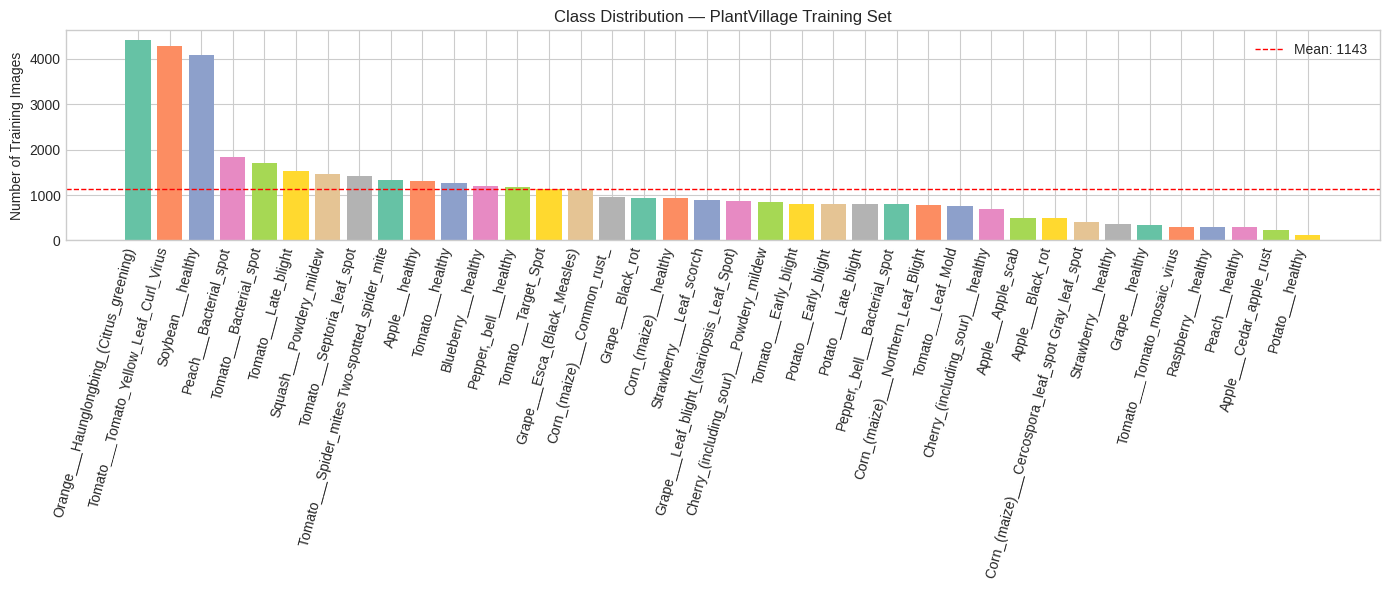

Most populated class : Orange___Haunglongbing_(Citrus_greening) (4405 images)
Least populated class: Potato___healthy (121 images)
Imbalance ratio       : 36.40x


In [ ]:
class_counts = {}
for c in class_names:
    class_path = os.path.join(TRAIN_DIR, c)
    class_counts[c] = len(os.listdir(class_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
df_counts = df_counts.sort_values("Image Count", ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(df_counts["Class"], df_counts["Image Count"], color=sns.color_palette("Set2", num_classes))
plt.xticks(rotation=75, ha='right')
plt.ylabel("Number of Training Images")
plt.title("Class Distribution — PlantVillage Training Set")
plt.axhline(df_counts["Image Count"].mean(), color='red', linestyle='--', linewidth=1, label=f"Mean: {df_counts['Image Count'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

imbalance_ratio = df_counts["Image Count"].max() / df_counts["Image Count"].min()
print(f"Most populated class : {df_counts.iloc[0]['Class']} ({df_counts.iloc[0]['Image Count']} images)")
print(f"Least populated class: {df_counts.iloc[-1]['Class']} ({df_counts.iloc[-1]['Image Count']} images)")
print(f"Imbalance ratio       : {imbalance_ratio:.2f}x")

# Image Property Audit — Size, Aspect Ratio, Corruption Check

Sampled 100 images across 5 classes
Width  range: 256–256 px (mean 256)
Height range: 256–256 px (mean 256)
Corrupted/unreadable files found: 0


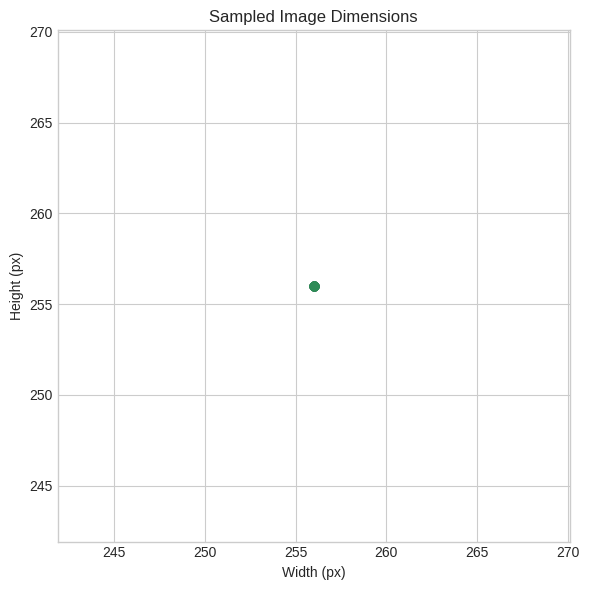

In [ ]:
sample_check_sizes = []
corrupted_files = []

sample_classes = pyrandom.sample(class_names, min(5, num_classes))

for c in sample_classes:
    class_path = os.path.join(TRAIN_DIR, c)
    images = os.listdir(class_path)[:20]
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as im:
                sample_check_sizes.append(im.size)
        except Exception:
            corrupted_files.append(img_path)

widths, heights = zip(*sample_check_sizes)
print(f"Sampled {len(sample_check_sizes)} images across {len(sample_classes)} classes")
print(f"Width  range: {min(widths)}–{max(widths)} px (mean {np.mean(widths):.0f})")
print(f"Height range: {min(heights)}–{max(heights)} px (mean {np.mean(heights):.0f})")
print(f"Corrupted/unreadable files found: {len(corrupted_files)}")

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.5, color='seagreen')
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Sampled Image Dimensions")
plt.tight_layout()
plt.show()

# Visual Preview — Sample Leaves per Class

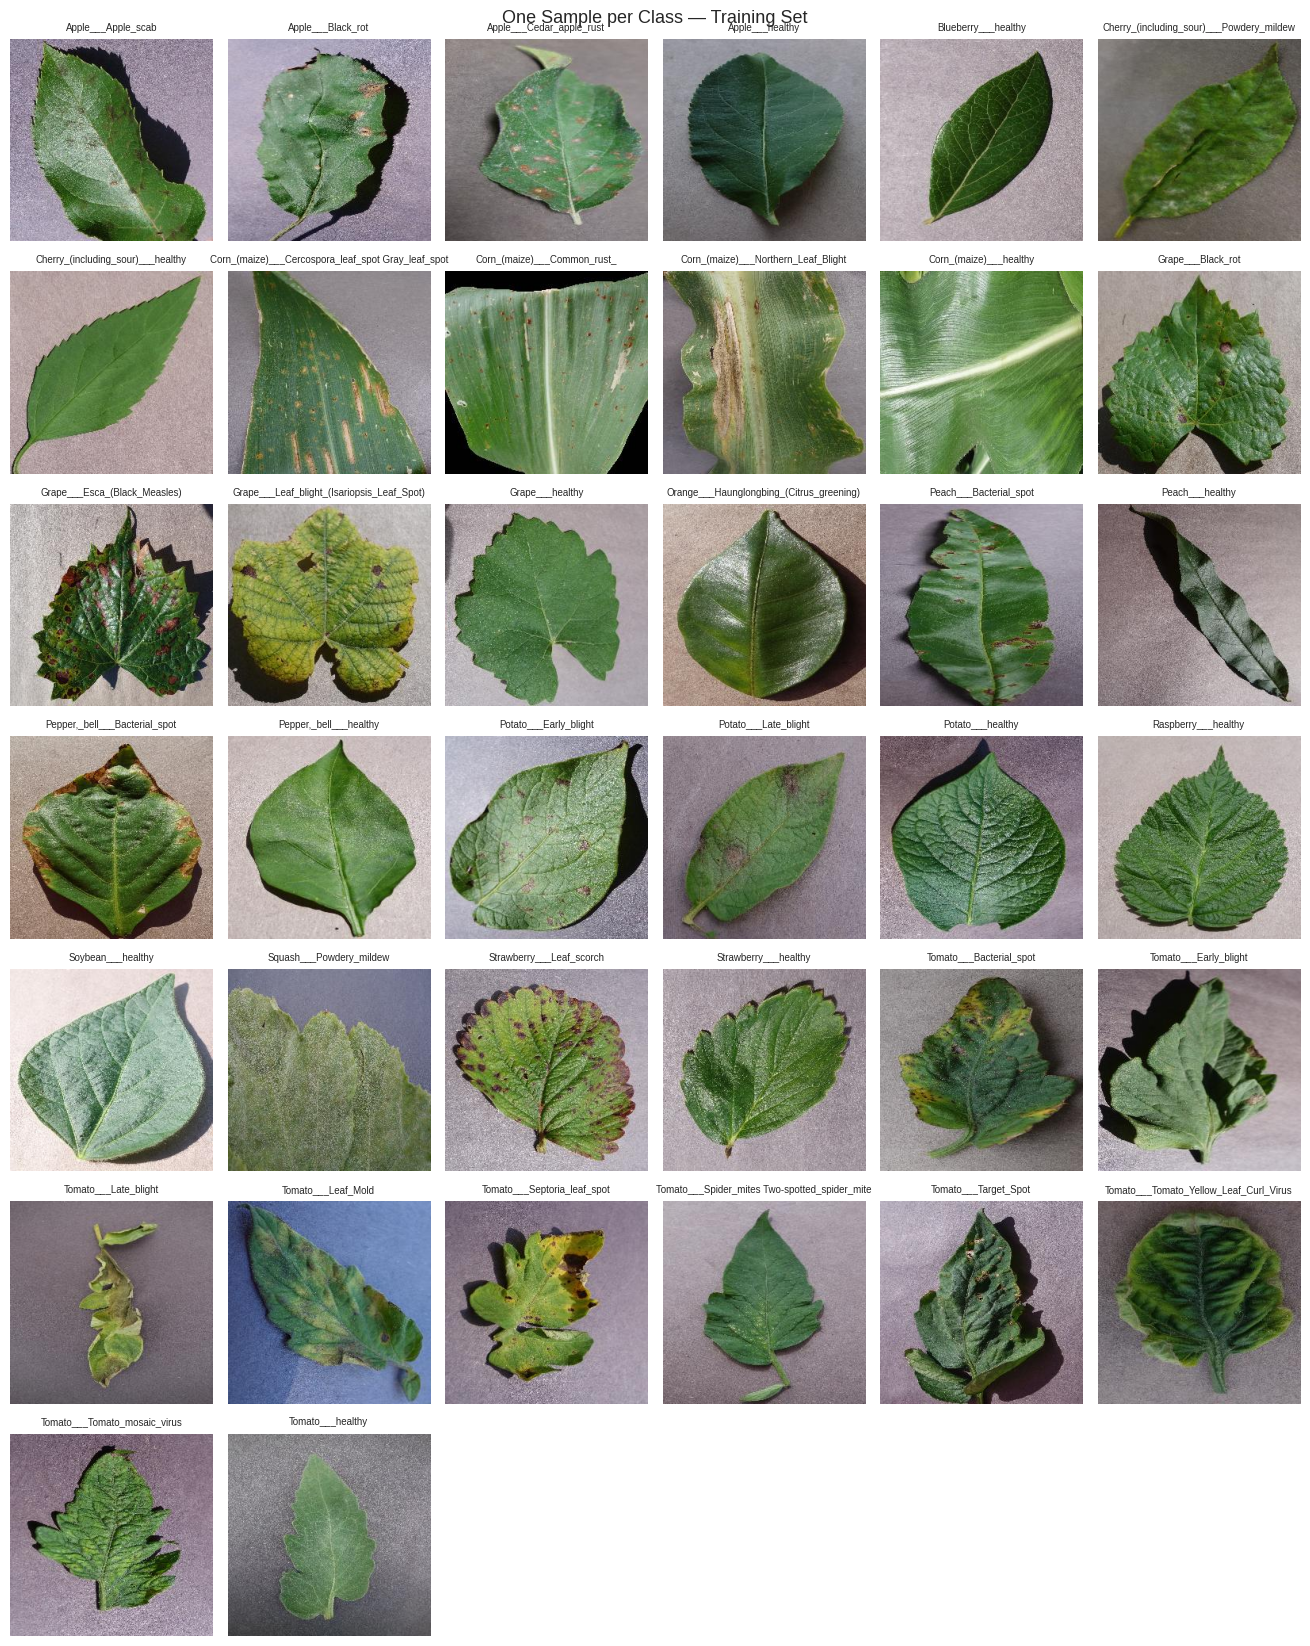

In [ ]:
def preview_class_samples(directory, class_list, samples_per_class=1):
    n = len(class_list)
    cols = 6
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 2.2, rows * 2.4))

    for i, c in enumerate(class_list, 1):
        class_path = os.path.join(directory, c)
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
        img_path = os.path.join(class_path, pyrandom.choice(img_files))

        plt.subplot(rows, cols, i)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(c, fontsize=7)
        plt.axis('off')

    plt.suptitle("One Sample per Class — Training Set", fontsize=13)
    plt.tight_layout()
    plt.show()

preview_class_samples(TRAIN_DIR, class_names)

# Train / Validation / Test Split

In [ ]:
os.makedirs(VAL_COPY_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

split_summary = []

for class_name in os.listdir(VAL_DIR):
    src_class_path = os.path.join(VAL_DIR, class_name)
    if not os.path.isdir(src_class_path):
        continue

    all_images = os.listdir(src_class_path)
    val_imgs, test_imgs = train_test_split(all_images, test_size=0.2, random_state=SEED)

    val_class_dir = os.path.join(VAL_COPY_DIR, class_name)
    test_class_dir = os.path.join(TEST_DIR, class_name)
    os.makedirs(val_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    for img in val_imgs:
        shutil.copy(os.path.join(src_class_path, img), os.path.join(val_class_dir, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_class_path, img), os.path.join(test_class_dir, img))

    split_summary.append({"Class": class_name, "Val": len(val_imgs), "Test": len(test_imgs)})

df_split = pd.DataFrame(split_summary)
print(df_split.to_string(index=False))
print(f"\nTotal validation images: {df_split['Val'].sum()}")
print(f"Total test images      : {df_split['Test'].sum()}")

                                             Class  Val  Test
                                  Tomato___healthy  254    64
                          Strawberry___Leaf_scorch  177    45
                                   Grape___healthy   67    17
                                Apple___Apple_scab  100    26
                          Apple___Cedar_apple_rust   44    11
            Tomato___Tomato_Yellow_Leaf_Curl_Virus  856   215
                                 Grape___Black_rot  188    48
                               Raspberry___healthy   59    15
                                 Apple___Black_rot  100    25
                 Cherry_(including_sour)___healthy  136    34
        Grape___Leaf_blight_(Isariopsis_Leaf_Spot)  172    43
                                   Apple___healthy  263    66
                             Tomato___Early_blight  160    40
                             Potato___Early_blight  160    40
                     Pepper,_bell___Bacterial_spot  160    40
        

# Data Augmentation & Generators

In [ ]:
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED
)

val_generator = eval_datagen.flow_from_directory(
    VAL_COPY_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"\n{num_classes} classes ready across train/val/test generators.")

Found 43444 images belonging to 38 classes.
Found 8676 images belonging to 38 classes.
Found 2185 images belonging to 38 classes.

38 classes ready across train/val/test generators.


# Augmentation Sanity Check — Before vs After

Found 43444 images belonging to 38 classes.


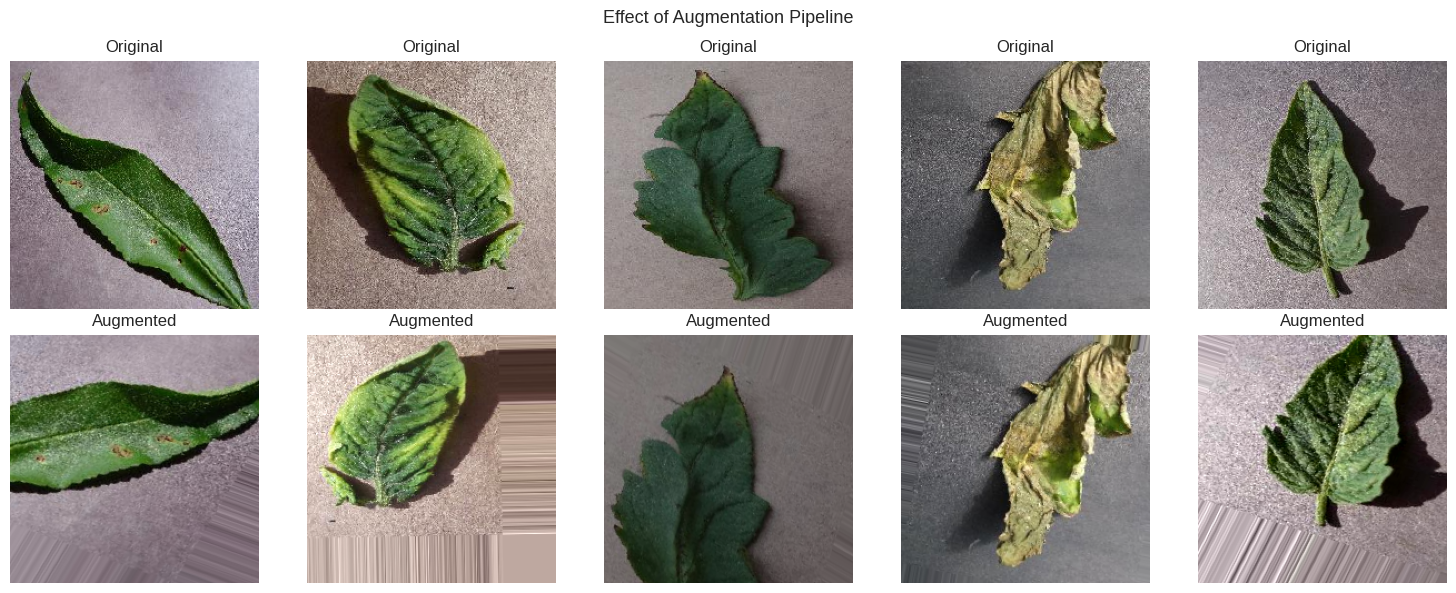

In [ ]:
raw_batch, _ = next(eval_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=5, shuffle=True, seed=SEED
))
aug_batch, _ = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(raw_batch[i])
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(aug_batch[i])
    axes[1, i].set_title("Augmented")
    axes[1, i].axis('off')

plt.suptitle("Effect of Augmentation Pipeline", fontsize=13)
plt.tight_layout()
plt.show()

# Callbacks : Shared across all models

In [ ]:
def get_callbacks(model_tag):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ModelCheckpoint(f"best_{model_tag}.keras", monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

print("Callback factory ready — call get_callbacks('cnn'), get_callbacks('vgg16'), etc.")

Callback factory ready — call get_callbacks('cnn'), get_callbacks('vgg16'), etc.


# Model 1 — Custom CNN (Baseline)

In [ ]:
def build_custom_cnn(input_shape, n_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(n_classes, activation='softmax')
    ], name="custom_cnn")
    return model

model_cnn = build_custom_cnn((IMG_HEIGHT, IMG_WIDTH, 3), num_classes)
model_cnn.compile(optimizer=Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,836,518 (37.52 MB)

 Trainable params: 9,836,070 (37.52 MB)

 Non-trainable params: 448 (1.75 KB)

# Training CNN

In [ ]:
history_cnn = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=get_callbacks('cnn')
)

Epoch 1/30
 333/1358 ━━━━━━━━━━━━━━━━━━━━ 1:56:41 7s/step - accuracy: 0.2028 - loss: 3.2835

KeyboardInterrupt: 

# Model 2 — VGG16 (Transfer Learning, Fine-Tuned)

In [ ]:
from tensorflow.keras.applications import VGG16

vgg16_base = VGG16(weights='imagenet', include_top=False,
                    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the early feature-extraction blocks (generic edges/textures),
# unfreeze only the last few conv blocks — full fine-tuning on a small
# dataset like this tends to overfit and destroy the pretrained weights.
for layer in vgg16_base.layers[:-4]:
    layer.trainable = False
for layer in vgg16_base.layers[-4:]:
    layer.trainable = True

model_vgg16 = Sequential([
    vgg16_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="vgg16_finetuned")

model_vgg16.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
model_vgg16.summary()

## Train VGG16

In [ ]:
history_vgg16 = model_vgg16.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=get_callbacks('vgg16')
)

# Model 3 — MobileNetV2 (Transfer Learning, Fine-Tuned)

In [ ]:
# MobileNetV2 is far lighter than VGG16 (fewer parameters, depthwise
# separable convolutions), making it the practical choice if this
# were ever deployed on a phone in the field — worth mentioning in
# your report as a reason for including it alongside VGG16.

from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(weights='imagenet', include_top=False,
                              input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Same reasoning as VGG16: freeze most of the pretrained backbone,
# only fine-tune the last handful of layers to adapt to leaf textures
# specifically, without destroying the general features ImageNet gave us.
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False
for layer in mobilenet_base.layers[-20:]:
    layer.trainable = True

model_mobilenet = Sequential([
    mobilenet_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="mobilenetv2_finetuned")

model_mobilenet.compile(optimizer=Adam(learning_rate=1e-5),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])
model_mobilenet.summary()

## Training MobileNetV2

In [ ]:
# ============================================================
# BLOCK 15b: Train MobileNetV2
# ============================================================
history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=get_callbacks('mobilenet')
)

# Model 4 — EfficientNetB0 (Transfer Learning, Fine-Tuned)

In [ ]:
# EfficientNetB0 uses compound scaling (balancing depth/width/resolution
# together rather than arbitrarily), and typically achieves higher
# accuracy than VGG16 or MobileNetV2 at a similar or smaller parameter
# count — a useful comparison point for your report's "why we chose
# these architectures" discussion.

from tensorflow.keras.applications import EfficientNetB0

# EfficientNet expects raw pixel values (0-255), NOT the /255 rescaling
# used for the other models — it has its own internal normalisation.
# So this model needs its OWN generators without the rescale=1./255 step.

train_datagen_eff = ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.3, horizontal_flip=True,
    brightness_range=[0.7, 1.3], channel_shift_range=20.0, fill_mode='nearest'
)
eval_datagen_eff = ImageDataGenerator()

train_generator_eff = train_datagen_eff.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED
)
val_generator_eff = eval_datagen_eff.flow_from_directory(
    VAL_COPY_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator_eff = eval_datagen_eff.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False,
                                    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

for layer in efficientnet_base.layers[:-20]:
    layer.trainable = False
for layer in efficientnet_base.layers[-20:]:
    layer.trainable = True

model_efficientnet = Sequential([
    efficientnet_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="efficientnetb0_finetuned")

model_efficientnet.compile(optimizer=Adam(learning_rate=1e-5),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
model_efficientnet.summary()

## Train EfficientNetB0

In [ ]:
history_efficientnet = model_efficientnet.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=20,
    callbacks=get_callbacks('efficientnet')
)

# Evaluation

## Generating Predictions on the Held-Out Test Set

In [ ]:
# Run this once per trained model. test_generator must have
# shuffle=False (it does, from Block 9) or predictions won't
# line up with true labels.

def get_predictions(model, generator):
    generator.reset()
    probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    y_true = generator.classes
    return y_true, y_pred, probs

y_true_cnn, y_pred_cnn, probs_cnn = get_predictions(model_cnn, test_generator)
y_true_vgg, y_pred_vgg, probs_vgg = get_predictions(model_vgg16, test_generator)

print("Predictions generated for CNN and VGG16 on the test set.")

NameError: name 'model_cnn' is not defined

## Classification Report — Precision / Recall / F1 per Class

In [ ]:
# Accuracy alone hides class-level weaknesses (e.g. a model that's
# 95% accurate overall but terrible at one rare disease class).
# This is why the marking criteria expect per-class analysis,
# not just a single headline number.

def print_classification_report(y_true, y_pred, class_names, model_name):
    print(f"\n{'='*60}\nClassification Report — {model_name}\n{'='*60}")
    report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
    print(report)
    return classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

report_cnn = print_classification_report(y_true_cnn, y_pred_cnn, class_names, "Custom CNN")
report_vgg = print_classification_report(y_true_vgg, y_pred_vgg, class_names, "VGG16 (Fine-tuned)")

## Confusion Matrix Heatmaps

In [ ]:
# Worth discussing in your report WHICH classes get confused with
# which e.g. two diseases that look visually similar are the
# interesting finding here, not just "the matrix looks mostly diagonal."

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=False, cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, cbar=True)
    plt.title(f"Normalised Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm_cnn = plot_confusion_matrix(y_true_cnn, y_pred_cnn, class_names, "Custom CNN")
cm_vgg = plot_confusion_matrix(y_true_vgg, y_pred_vgg, class_names, "VGG16 (Fine-tuned)")

## Identify the Most-Confused Class Pairs

In [ ]:
# Automates finding the specific confusions worth discussing in
# prose, instead of eyeballing a 15x15 heatmap and guessing.

def top_confused_pairs(cm, class_names, top_n=5):
    confusions = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                confusions.append((class_names[i], class_names[j], cm[i, j]))

    confusions.sort(key=lambda x: x[2], reverse=True)
    df = pd.DataFrame(confusions[:top_n], columns=["Actual", "Predicted As", "Count"])
    return df

print("Top confusions — Custom CNN:")
print(top_confused_pairs(cm_cnn, class_names).to_string(index=False))

print("\nTop confusions — VGG16:")
print(top_confused_pairs(cm_vgg, class_names).to_string(index=False))

##  ROC-AUC (One-vs-Rest, Multi-class)

In [ ]:
# AUC per class gives a threshold-independent view of separability,
# useful alongside accuracy since accuracy can be misleading on an
# imbalanced dataset (see your Block 5 imbalance ratio).

from sklearn.preprocessing import label_binarize

def compute_multiclass_auc(y_true, probs, class_names):
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    auc_scores = {}
    for i, cname in enumerate(class_names):
        try:
            auc_scores[cname] = roc_auc_score(y_true_bin[:, i], probs[:, i])
        except ValueError:
            auc_scores[cname] = np.nan  # class absent from this test split
    return auc_scores

auc_cnn = compute_multiclass_auc(y_true_cnn, probs_cnn, class_names)
auc_vgg = compute_multiclass_auc(y_true_vgg, probs_vgg, class_names)

df_auc = pd.DataFrame({
    "Class": class_names,
    "AUC (CNN)": [auc_cnn[c] for c in class_names],
    "AUC (VGG16)": [auc_vgg[c] for c in class_names]
})
print(df_auc.to_string(index=False))
print(f"\nMean AUC — CNN: {df_auc['AUC (CNN)'].mean():.3f}")
print(f"Mean AUC — VGG16: {df_auc['AUC (VGG16)'].mean():.3f}")

## Training History Comparison — Overfitting Check

In [ ]:
# Plotting train vs val curves side by side is how you actually
# demonstrate whether a model overfit — a claim your report needs
# to make with evidence, not just assert.

def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f"{model_name} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f"{model_name} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn, "Custom CNN")
plot_training_history(history_vgg16, "VGG16 (Fine-tuned)")

## Final Model Comparison Table

In [ ]:
# This is the single table your Evaluation chapter will likely
# lead with — keep it, and write the surrounding paragraph about
# WHY the differences exist, not just what the numbers are.

comparison_data = {
    "Model": ["Custom CNN", "VGG16 (Fine-tuned)"],
    "Test Accuracy": [
        accuracy_score(y_true_cnn, y_pred_cnn),
        accuracy_score(y_true_vgg, y_pred_vgg)
    ],
    "Macro Precision": [
        precision_score(y_true_cnn, y_pred_cnn, average='macro'),
        precision_score(y_true_vgg, y_pred_vgg, average='macro')
    ],
    "Macro Recall": [
        recall_score(y_true_cnn, y_pred_cnn, average='macro'),
        recall_score(y_true_vgg, y_pred_vgg, average='macro')
    ],
    "Macro F1": [
        f1_score(y_true_cnn, y_pred_cnn, average='macro'),
        f1_score(y_true_vgg, y_pred_vgg, average='macro')
    ],
    "Mean AUC": [
        df_auc['AUC (CNN)'].mean(),
        df_auc['AUC (VGG16)'].mean()
    ],
    "Trainable Params": [
        model_cnn.count_params(),
        model_vgg16.count_params()
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison.iloc[:, 1:5] = df_comparison.iloc[:, 1:5].round(4)
print(df_comparison.to_string(index=False))

df_comparison.to_csv("model_comparison.csv", index=False)
print("\nSaved as model_comparison.csv — reference this table directly in your Evaluation chapter.")

# Grad-CAM — Core Implementation

In [ ]:
# Grad-CAM highlights which regions of an image most influenced
# the model's prediction, by looking at gradients flowing into
# the last convolutional layer. This is what lets you argue the
# model is actually looking at lesions/discoloured tissue, rather
# than background or unrelated leaf shape.

import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

print("Grad-CAM function ready.")

## Finding the Last Convolutional Layer Automatically

In [ ]:
# Different architectures name their layers differently — this
# avoids hardcoding a layer name that breaks if you swap models.

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        # for models wrapped in a Sequential containing a base model
        if hasattr(layer, 'layers'):
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    return sublayer.name
    raise ValueError("No Conv2D layer found in model.")

last_conv_cnn = find_last_conv_layer(model_cnn)
last_conv_vgg = find_last_conv_layer(model_vgg16)

print(f"Custom CNN last conv layer : {last_conv_cnn}")
print(f"VGG16 last conv layer      : {last_conv_vgg}")

## Overlay Heatmap on Original Image

In [ ]:
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    overlayed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)

## Running Grad-CAM on Examples from the Confused Class Pairs

In [ ]:
# Deliberately pulling images from Block 22's confusion analysis,
# rather than random images this gives Grad-CAM a purpose:
# showing WHY two diseases get mixed up, not just decoration.

def preprocess_single_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

def gradcam_for_class(model, class_name, last_conv_layer, n_samples=2):
    class_dir = os.path.join(TEST_DIR, class_name)
    sample_files = pyrandom.sample(os.listdir(class_dir), min(n_samples, len(os.listdir(class_dir))))

    fig, axes = plt.subplots(len(sample_files), 2, figsize=(8, 4 * len(sample_files)))
    if len(sample_files) == 1:
        axes = axes.reshape(1, -1)

    for i, fname in enumerate(sample_files):
        img_path = os.path.join(class_dir, fname)
        img_array = preprocess_single_image(img_path)

        heatmap, pred_idx = make_gradcam_heatmap(img_array, model, last_conv_layer)
        overlay = overlay_gradcam(img_path, heatmap)

        original = cv2.cvtColor(cv2.resize(cv2.imread(img_path), (IMG_WIDTH, IMG_HEIGHT)), cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"True: {class_name}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f"Grad-CAM (Pred: {class_names[pred_idx]})")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Example: picking the top confused class from Block 22's output for VGG16
top_confusion = top_confused_pairs(cm_vgg, class_names, top_n=1)
confused_class = top_confusion.iloc[0]["Actual"]

print(f"Running Grad-CAM on: {confused_class}")
gradcam_for_class(model_vgg16, confused_class, last_conv_vgg)

# Thank You